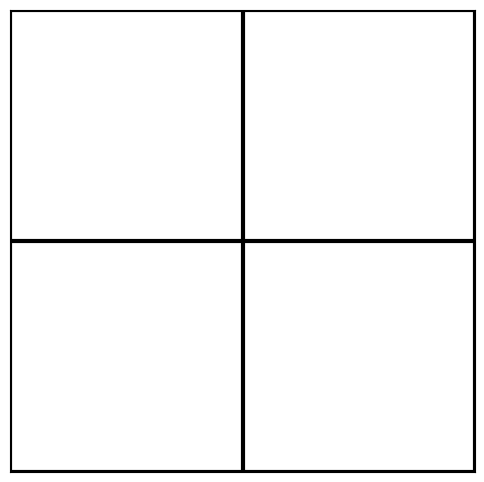

In [8]:
from sudoku_nisq.q_sudoku import QSudoku

puzzle = QSudoku.generate(size=2, num_missing_cells=4)
puzzle.plot_puzzle()

In [9]:
puzzle.subgrid_size

1

In [22]:
from sudoku_nisq import ExactCoverQuantumSolver

puzzle.set_solver(ExactCoverQuantumSolver, encoding="simple")


In [23]:
circuit = puzzle.build_circuit()

In [24]:
circuit.n_qubits

45

In [25]:
circuit.depth()

338

# Generate Qiskit and PyTKET circuits

This section builds circuits for both "simple" and "pattern" encodings using PyTKET and Qiskit. If Qiskit isn’t installed, the Qiskit cells will print a helpful hint.

In [3]:
# Helpers for setting the solver and summarizing circuits
from sudoku_nisq import ExactCoverQuantumSolver, ExactCoverEncoding
from sudoku_nisq.sudoku_pattern_generation import PatternGeneration


def set_exact_cover_solver_for(puzzle, encoding: str = "simple"):
    """Set ExactCover solver on `puzzle` for the requested encoding.
    Handles the 2x2 special case by injecting 2x2-specific universe/subsets.
    Returns the active solver.
    """
    if puzzle.subgrid_size >= 2:
        puzzle.set_solver(ExactCoverQuantumSolver, encoding=encoding)
        return puzzle._solver
    # 2x2 special-case: use 2x2 universe/subsets helpers
    enc = ExactCoverEncoding(puzzle.puzzle)
    if encoding == "simple":
        subsets = enc.gen_simple_subsets2x2()
    elif encoding == "pattern":
        pat = PatternGeneration(puzzle.puzzle)
        subsets = enc.gen_patterns_subsets2x2(pat.patterns, puzzle.puzzle.pre_tuples)
    else:
        raise ValueError(f"Unknown encoding: {encoding}")
    puzzle.set_solver(
        ExactCoverQuantumSolver,
        encoding=encoding,
        universe=getattr(enc, "universe2x2", []),
        subsets=subsets,
    )
    return puzzle._solver


def summarize_circuit(circ):
    try:
        # pytket Circuit
        n_qubits = getattr(circ, "n_qubits", None)
        n_gates = getattr(circ, "n_gates", None)
        if n_qubits is not None and n_gates is not None:
            print(f"Circuit summary (PyTKET): qubits={n_qubits}, gates={n_gates}")
            return
        # Qiskit QuantumCircuit
        from qiskit.circuit import QuantumCircuit  # type: ignore
        if isinstance(circ, QuantumCircuit):
            gate_count = sum(circ.count_ops().values()) if hasattr(circ, 'count_ops') else None
            print(f"Circuit summary (Qiskit): qubits={circ.num_qubits}, gates={gate_count}")
            return
    except Exception:
        pass
    # Fallback
    print(f"Circuit built: type={type(circ)}")

## Simple Encoding — PyTKET

In [4]:
# Build PyTKET circuit for simple encoding
solver_simple = set_exact_cover_solver_for(puzzle, encoding="simple")
ptk_simple = puzzle.build_circuit()
summarize_circuit(ptk_simple)
# Optional: visualize in notebooks with pytket's renderer
puzzle.draw_circuit(ptk_simple)

IndexError: list assignment index out of range

## Simple Encoding — Qiskit

In [ ]:
# Build Qiskit circuit for simple encoding
try:
    import qiskit as qk  # type: ignore
    qk_simple = puzzle._solver.build_main_circuit(backend=qk)
    summarize_circuit(qk_simple)
    try:
        # Text drawer avoids mpl dependency
        print(qk_simple.draw(output="text"))
    except Exception:
        pass
except ImportError:
    print("Qiskit not available. Install with: pip install qiskit")

## Pattern Encoding — PyTKET

In [ ]:
# Build PyTKET circuit for pattern encoding
solver_pattern = set_exact_cover_solver_for(puzzle, encoding="pattern")
ptk_pattern = puzzle.build_circuit()
summarize_circuit(ptk_pattern)
# Optional: visualize
# puzzle.draw_circuit(ptk_pattern)

## Pattern Encoding — Qiskit

In [ ]:
# Build Qiskit circuit for pattern encoding
try:
    import qiskit as qk  # type: ignore
    qk_pattern = puzzle._solver.build_main_circuit(backend=qk)
    summarize_circuit(qk_pattern)
    try:
        print(qk_pattern.draw(output="text"))
    except Exception:
        pass
except ImportError:
    print("Qiskit not available. Install with: pip install qiskit")